In [1]:
# -------------------------------
# Importing necessary libraries
# -------------------------------

# "datasets" library from Hugging Face to load pre-built datasets
from datasets import load_dataset

# Scikit-learn tools for splitting the data and scaling features
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import VarianceThreshold

# Imbalanced-learn method to handle imbalanced datasets
from imblearn.combine import SMOTEENN

# Import the seaborn library for advanced statistical visualizations
import seaborn as sns

# Import matplotlib.pyplot for creating and customizing plots
import matplotlib.pyplot as plt

# Import NumPy for arrays, matrices, and mathematical operations
import numpy as np

# Pandas for data manipulation and analysis
import pandas as pd

In [2]:
# -------------------------------
# Load the dataset and convert to Pandas DataFrame
# -------------------------------

# Load the fraud detection dataset from Hugging Face
dataset = load_dataset("CiferAI/Cifer-Fraud-Detection-Dataset-AF")

# Convert the training split of the dataset to a Pandas DataFrame for easier manipulation
df = dataset["train"].to_pandas()
df = df.sample(200000, random_state=42)

# Convert columns to the best possible dtypes (e.g., int64 → Int64, object → string)
# This helps prevent potential type issues and ensures consistent data types
df = df.convert_dtypes()

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
9811966,147,CASH_IN,329822.99,sdv-pii-1hybr,4806431.42,5947257.03,sdv-pii-a89t7,419530.31,3697373.7,0,0
3361606,450,PAYMENT,20295.13,C1114778583,0.01,499.17,C689793442,4467189.32,1290654.24,0,0
12871380,57,CASH_OUT,32781.69,sdv-pii-suuas,143.37,20.69,sdv-pii-k2ai2,1129675.95,4979770.75,0,0
20899941,210,CASH_OUT,94808.87,C1629867471,974.7,32834.22,C350001556,526137.5,3.11,0,0
4740903,362,CASH_OUT,84063.92,C1758188565,192732.65,417339.55,M1856647425,1131265.84,4833.99,0,0


In [4]:
# -------------------------------
# One-Hot Encoding and Feature Cleanup
# -------------------------------

# Apply one-hot encoding to the "type" column
# - Each transaction type becomes a separate binary column
# - drop_first=False keeps all categories (useful if no baseline is needed)
df = pd.get_dummies(df, columns=["type"], drop_first=False)

# Drop identifier columns that are not useful for modeling
# - "nameOrig" and "nameDest" are anonymized IDs and not predictive
df.drop(columns=["nameDest", "nameOrig"], inplace=True)

# Keep only the numerical columns in the DataFrame, since correlation analysis
# requires numeric data. Then convert all these columns to standard float dtype.
# This ensures that any Pandas extension types (e.g., Int64, Float64 with pd.NA)
# are converted into regular float columns where missing values become np.nan.
df = df.select_dtypes(include=["number"]).astype(float)

In [5]:
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
9811966,147.0,329822.99,4806431.42,5947257.03,419530.31,3697373.70,0.0,0.0
3361606,450.0,20295.13,0.01,499.17,4467189.32,1290654.24,0.0,0.0
12871380,57.0,32781.69,143.37,20.69,1129675.95,4979770.75,0.0,0.0
20899941,210.0,94808.87,974.70,32834.22,526137.50,3.11,0.0,0.0
4740903,362.0,84063.92,192732.65,417339.55,1131265.84,4833.99,0.0,0.0


In [6]:
X = df.drop("isFraud", axis=1)
y = df["isFraud"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [8]:
# -----------------------------------------------------------
# Apply SMOTEENN to handle class imbalance on the training set.
# SMOTEENN combines oversampling (SMOTE) and cleaning (ENN),
# improving minority class representation while removing noisy samples.
# -----------------------------------------------------------

smote_enn = SMOTEENN(random_state=42)
X_train, y_train = smote_enn.fit_resample(X_train, y_train)

In [9]:
# ------------------------------------------------------------
# Evaluate on validation and test sets
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model, X, y, title="Dataset"):
    """Evaluate model performance on a given dataset."""
    preds = model.predict(X)
    proba = model.predict_proba(X)[:, 1]

    print("\n-------------------------------------------")
    print(f"Evaluation on: {title}")
    print("-------------------------------------------")
    print(f"Accuracy:       {accuracy_score(y, preds):.4f}")
    print(f"Precision:      {precision_score(y, preds):.4f}")
    print(f"Recall:         {recall_score(y, preds):.4f}")
    print(f"F1-score:       {f1_score(y, preds):.4f}")
    print(f"ROC-AUC:        {roc_auc_score(y, proba):.4f}")

    print("\nClassification report:")
    print(classification_report(y, preds, digits=4))

    # Confusion matrix
    cm = confusion_matrix(y, preds)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Training baseline RandomForest model...

-------------------------------------------
Evaluation on: Training Set
-------------------------------------------
Accuracy:       0.7950
Precision:      0.7183
Recall:         0.9914
F1-score:       0.8330
ROC-AUC:        0.9027

Classification report:
              precision    recall  f1-score   support

         0.0     0.9845    0.5856    0.7344    149607
         1.0     0.7183    0.9914    0.8330    159459

    accuracy                         0.7950    309066
   macro avg     0.8514    0.7885    0.7837    309066
weighted avg     0.8472    0.7950    0.7853    309066



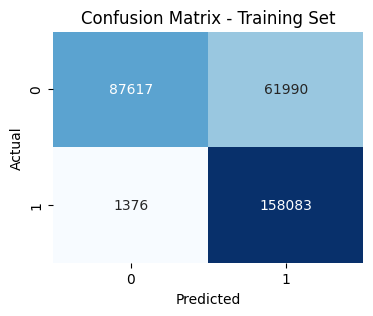


-------------------------------------------
Evaluation on: Test Set
-------------------------------------------
Accuracy:       0.5770
Precision:      0.0014
Recall:         0.4423
F1-score:       0.0027
ROC-AUC:        0.5276

Classification report:
              precision    recall  f1-score   support

         0.0     0.9987    0.5772    0.7316     39948
         1.0     0.0014    0.4423    0.0027        52

    accuracy                         0.5770     40000
   macro avg     0.5001    0.5098    0.3672     40000
weighted avg     0.9974    0.5770    0.7306     40000



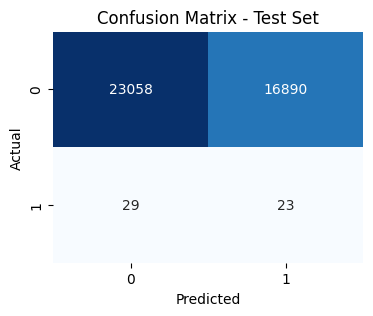

In [10]:
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Train a simple baseline model (Random Forest)
# ------------------------------------------------------------

print("Training baseline RandomForest model...")

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Train on the resampled training set (after SMOTE)
model.fit(X_train, y_train)

# ------------------------------------------------------------
# Run evaluation on training and test sets
# ------------------------------------------------------------

evaluate_model(model, X_train, y_train, title="Training Set")
evaluate_model(model, X_test, y_test, title="Test Set")

TRAINING XGBOOST MODEL


c:\Users\DELL\Documents\ProjetEcole\Financial-Fraud-Detection\python_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [09:13:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



-------------------------------------------
Evaluation on: XGBoost - Training Set
-------------------------------------------
Accuracy:       0.9915
Precision:      0.9838
Recall:         1.0000
F1-score:       0.9918
ROC-AUC:        0.9999

Classification report:
              precision    recall  f1-score   support

         0.0     1.0000    0.9825    0.9911    149607
         1.0     0.9838    1.0000    0.9918    159459

    accuracy                         0.9915    309066
   macro avg     0.9919    0.9912    0.9915    309066
weighted avg     0.9916    0.9915    0.9915    309066



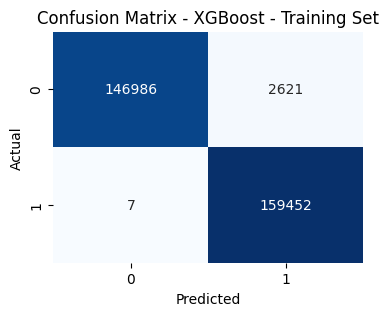


-------------------------------------------
Evaluation on: XGBoost - Test Set
-------------------------------------------
Accuracy:       0.9651
Precision:      0.0022
Recall:         0.0577
F1-score:       0.0043
ROC-AUC:        0.5527

Classification report:
              precision    recall  f1-score   support

         0.0     0.9987    0.9663    0.9823     39948
         1.0     0.0022    0.0577    0.0043        52

    accuracy                         0.9651     40000
   macro avg     0.5005    0.5120    0.4933     40000
weighted avg     0.9974    0.9651    0.9810     40000



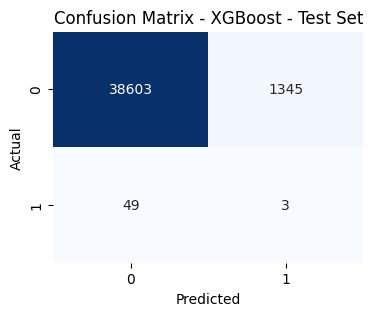

In [11]:
# ============================================================================
# MODEL : XGBoost Classifier
# ============================================================================

import xgboost as xgb


print("TRAINING XGBOOST MODEL")


xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_model.fit(X_train, y_train)

# Evaluate
evaluate_model(xgb_model, X_train, y_train, title="XGBoost - Training Set")
evaluate_model(xgb_model, X_test, y_test, title="XGBoost - Test Set")
    


TRAINING LOGISTIC REGRESSION MODEL


c:\Users\DELL\Documents\ProjetEcole\Financial-Fraud-Detection\python_env\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



-------------------------------------------
Evaluation on: Logistic Regression - Training Set
-------------------------------------------
Accuracy:       0.5041
Precision:      0.5299
Recall:         0.3431
F1-score:       0.4165
ROC-AUC:        0.5518

Classification report:
              precision    recall  f1-score   support

         0.0     0.4911    0.6757    0.5688    149607
         1.0     0.5299    0.3431    0.4165    159459

    accuracy                         0.5041    309066
   macro avg     0.5105    0.5094    0.4926    309066
weighted avg     0.5111    0.5041    0.4902    309066



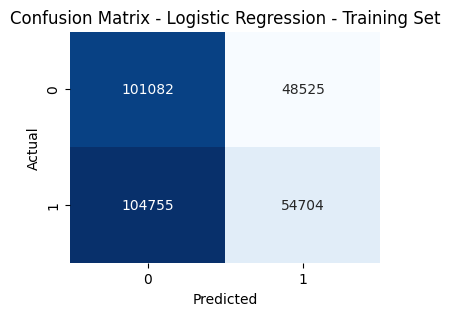


-------------------------------------------
Evaluation on: Logistic Regression - Test Set
-------------------------------------------
Accuracy:       0.6757
Precision:      0.0016
Recall:         0.4038
F1-score:       0.0032
ROC-AUC:        0.5411

Classification report:
              precision    recall  f1-score   support

         0.0     0.9989    0.6761    0.8063     39948
         1.0     0.0016    0.4038    0.0032        52

    accuracy                         0.6757     40000
   macro avg     0.5002    0.5400    0.4048     40000
weighted avg     0.9976    0.6757    0.8053     40000



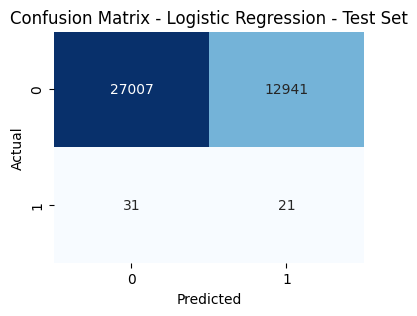

In [12]:
# ============================================================================
# MODEL: Logistic Regression
# ============================================================================
from sklearn.linear_model import LogisticRegression

print("TRAINING LOGISTIC REGRESSION MODEL")

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    solver='saga',  # Fast solver for large datasets
    penalty='l2'
)

lr_model.fit(X_train, y_train)

# Evaluate
evaluate_model(lr_model, X_train, y_train, title="Logistic Regression - Training Set")
evaluate_model(lr_model, X_test, y_test, title="Logistic Regression - Test Set")